## Mental Health Detection with LoRA Fine Tuning using Mistral 7B

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes

In [13]:
import warnings
import logging
from transformers import logging as transformers_logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

transformers_logging.set_verbosity_error()

In [14]:
import pandas as pd
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import Dataset

train = pd.read_csv('/content/drive/MyDrive/train.csv')
val   = pd.read_csv('/content/drive/MyDrive/val.csv')
test  = pd.read_csv('/content/drive/MyDrive/test.csv')

In [5]:
# @title Initialize model

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-v0.3-bnb-4bit",
    max_seq_length = 65536,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.5.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


But with kaiokendev's RoPE scaling of 2.0, it can be magically be extended to 65536!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

In [4]:
# @title Run to set model in Training mode
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

In [16]:
# @title Run to set model in Testing mode - modify path as appropriate
# model.load_adapter("/content/drive/MyDrive/NLP_Project/adapter_train_subset_10000_v2", "model_10000")

model.set_adapter("model_10000")

In [7]:
# @title Training functions
from unsloth.chat_templates import train_on_responses_only

def prep_dataset(dataset, tokenizer):
  text = dataset['text']
  labels = dataset['label']

  formatted_data = []

  for text, label in zip(text, labels):
    formatted_text = f"<s>[INST] Is this person who wrote this depressed or not depressed? Answer 1 if depressed and 0 if not. Text: {text} [/INST] {label} </s>"
    formatted_data.append(formatted_text)

  return Dataset.from_dict({ "text": formatted_data })


def train_model(model, tokenizer, train_data, model_name, eval_data=None):
  trainer = SFTTrainer(
      model = model,
      tokenizer = tokenizer,
      train_dataset = train_data,
      eval_dataset = eval_data,
      dataset_text_field = "text",
      max_seq_length = 8192,
      args = TrainingArguments(
          per_device_train_batch_size = 2,
          gradient_accumulation_steps = 4,
          warmup_steps = 5,
          num_train_epochs = 3,
          learning_rate = 2e-4,
          eval_strategy="steps",
          eval_steps=50,
          bf16 = True,
          optim = "adamw_8bit",
          logging_steps = 1,
          output_dir = model_name,
          save_strategy = "no", # Don't save checkpoints to save disk space
      ),
  )
  trainer = train_on_responses_only(
    trainer,
    instruction_part = "[INST]",
    response_part = "[/INST]",
  )

  print(f"Beginning training for {model_name}.")
  trainer.train()
  model.save_pretrained(f"/content/drive/MyDrive/NLP_Project/adapter_{model_name}")
  print(f"Training finished. Model saved as adapter_{model_name}")

In [ ]:
# @title 2 row training
# one of each label
row_0 = train[train['label'] == 0].sample(n=1, random_state=42)
row_1 = train[train['label'] == 1].sample(n=1, random_state=42)

train_subset_2 = pd.concat([row_0, row_1])

formatted_train_1 = prep_dataset(train_subset_2, tokenizer)

train_model(model, tokenizer, formatted_train_1, "train_subset_2")

num_proc must be <= 2. Reducing num_proc to 2 for dataset of size 2.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2 [00:00<?, ? examples/s]

Beginning training for train_subset_2.
{'loss': '2.399', 'grad_norm': '1.524', 'learning_rate': '0', 'epoch': '1'}
{'train_runtime': '0.8751', 'train_samples_per_second': '2.286', 'train_steps_per_second': '1.143', 'train_loss': '2.399', 'epoch': '1'}
Training finished. Model saved as adapter_train_subset_2


In [ ]:
# @title Training with 100 rows
train_subset_100 = train.sample(n=100, random_state=42)
formatted_train_100 = prep_dataset(train_subset_100, tokenizer)

val_subset = val.sample(n=10, random_state=42)
formatted_val_10 = prep_dataset(val_subset, tokenizer)

train_model(model, tokenizer, formatted_train_100, "train_subset_100", eval_data=formatted_val_10)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/100 [00:00<?, ? examples/s]

num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.


Unsloth: Tokenizing ["text"] (num_proc=10):   0%|          | 0/10 [00:00<?, ? examples/s]

Beginning training for train_subset_100.
{'loss': '2.226', 'grad_norm': '1.001', 'learning_rate': '0', 'epoch': '0.08'}
{'loss': '2.198', 'grad_norm': '1.123', 'learning_rate': '4e-05', 'epoch': '0.16'}
{'loss': '2.214', 'grad_norm': '1.442', 'learning_rate': '8e-05', 'epoch': '0.24'}
{'loss': '2.254', 'grad_norm': '0.9385', 'learning_rate': '0.00012', 'epoch': '0.32'}
{'loss': '2.161', 'grad_norm': '1.688', 'learning_rate': '0.00016', 'epoch': '0.4'}
{'loss': '2.132', 'grad_norm': '1.437', 'learning_rate': '0.0002', 'epoch': '0.48'}
{'loss': '2.153', 'grad_norm': '1.067', 'learning_rate': '0.000175', 'epoch': '0.56'}
{'loss': '2.237', 'grad_norm': '0.7788', 'learning_rate': '0.00015', 'epoch': '0.64'}
{'loss': '2.133', 'grad_norm': '1.006', 'learning_rate': '0.000125', 'epoch': '0.72'}
{'loss': '2.26', 'grad_norm': '1.525', 'learning_rate': '0.0001', 'epoch': '0.8'}
{'loss': '2.185', 'grad_norm': '2.318', 'learning_rate': '7.5e-05', 'epoch': '0.88'}
{'loss': '2.203', 'grad_norm': '1.0

In [21]:
# @title Training with 1000 rows
train_subset_1000 = train.sample(n=1000, random_state=42)
formatted_train_1000 = prep_dataset(train_subset_1000, tokenizer)

val_subset = val.sample(n=100, random_state=42)
formatted_val_100 = prep_dataset(val_subset, tokenizer)

train_model(model, tokenizer, formatted_train_1000, "train_subset_1000_v2", eval_data=formatted_val_100)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1000 [00:00<?, ? examples/s]

Beginning training for train_subset_1000_v2.
{'loss': '2.898', 'grad_norm': '1.841', 'learning_rate': '0', 'epoch': '0.008'}
{'loss': '2.69', 'grad_norm': '1.761', 'learning_rate': '4e-05', 'epoch': '0.016'}
{'loss': '2.614', 'grad_norm': '1.206', 'learning_rate': '8e-05', 'epoch': '0.024'}
{'loss': '2.842', 'grad_norm': '1.511', 'learning_rate': '0.00012', 'epoch': '0.032'}
{'loss': '3.148', 'grad_norm': '3.825', 'learning_rate': '0.00016', 'epoch': '0.04'}
{'loss': '1.932', 'grad_norm': '2.891', 'learning_rate': '0.0002', 'epoch': '0.048'}
{'loss': '2.57', 'grad_norm': '1.55', 'learning_rate': '0.0001983', 'epoch': '0.056'}
{'loss': '2.235', 'grad_norm': '1.404', 'learning_rate': '0.0001967', 'epoch': '0.064'}
{'loss': '2.271', 'grad_norm': '0.7202', 'learning_rate': '0.000195', 'epoch': '0.072'}
{'loss': '2.203', 'grad_norm': '1.164', 'learning_rate': '0.0001933', 'epoch': '0.08'}
{'loss': '2.228', 'grad_norm': '1.161', 'learning_rate': '0.0001917', 'epoch': '0.088'}
{'loss': '2.226

In [9]:
# @title Training with 10000 rows
train_subset_10000 = train.sample(n=10000, random_state=30)
formatted_train_10000 = prep_dataset(train_subset_10000, tokenizer)

val_subset = val.sample(n=1000, random_state=30)
formatted_val_1000 = prep_dataset(val_subset, tokenizer)

train_model(model, tokenizer, formatted_train_10000, "train_subset_10000_v2", eval_data=formatted_val_1000)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/10000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1000 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/10000 [00:00<?, ? examples/s]

Unsloth: Removed 295 out of 10000 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


Map (num_proc=16):   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Removed 23 out of 1000 samples from eval_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.
Beginning training for train_subset_10000_v2.
{'loss': '0.1275', 'grad_norm': '1.265', 'learning_rate': '0', 'epoch': '0.0008242'}
{'loss': '0.1188', 'grad_norm': '1.203', 'learning_rate': '4e-05', 'epoch': '0.001648'}
{'loss': '0.07238', 'grad_norm': '0.9844', 'learning_rate': '8e-05', 'epoch': '0.002473'}
{'loss': '0.07305', 'grad_norm': '0.9107', 'learning_rate': '0.00012', 'epoch': '0.003297'}
{'loss': '0.07589', 'grad_norm': '1.447', 'learning_rate': '0.00016', 'epoch': '0.004121'}
{'loss': '0.03513', 'grad_norm': '1.048', 'learning_rate': '0.0002', 'epoch': '0.004945'}
{'loss': '0.1441', 'grad_norm': '7.991', 'learning_rate': '0.0001999', 'epoch': '0.00577'}
{'loss': '0.01633', 'grad_norm': '0.4388', 'learning_rate': '0.0001999', 'epoch': '0.006594'}
{'loss': '0.04791', 'grad_norm': '2.168', 'learning_rate': '0.0001998'

In [9]:
# @title Testing function - Adjust checkpoint_path for larger datasets
from sklearn.metrics import classification_report
from tqdm import tqdm
import json
import os

def test_model(model, tokenizer, test_data, checkpoint_path='/content/drive/MyDrive/nlp_test_checkpoint.json'):
  FastLanguageModel.for_inference(model)

  y_true = test_data['label'].tolist()

  # Load checkpoint if resuming
  if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    y_pred = checkpoint['y_pred']
    start_idx = len(y_pred)
    print(f"Resuming from checkpoint — {start_idx}/{len(test_data)} samples already done")
  else:
    y_pred = []
    start_idx = 0

  texts = test_data['text'].tolist()

  for i, text in enumerate(tqdm(texts[start_idx:], initial=start_idx, total=len(texts))):
    actual_idx = i + start_idx

    try:
      inputs = tokenizer(
        [f"<s>[INST] Is this person who wrote this depressed or not depressed? Answer 1 if depressed and 0 if not. Do not output anything else. Text: {text} [/INST]"],
        return_tensors="pt",
        truncation=True,
        max_length=65536
      ).to("cuda")

      outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id
      )

      prediction = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:])[0]
      clean_pred = prediction.strip()
      y_pred.append(1 if '1' in clean_pred else 0)

    except Exception as e:
      print(f"\nError on sample {actual_idx}: {e} — defaulting to 0")
      y_pred.append(0)

    # Save checkpoint every 100 samples
    if actual_idx % 1000 == 0:
      with open(checkpoint_path, 'w') as f:
        json.dump({'y_pred': y_pred, 'completed': actual_idx}, f)
      print(f"\nCheckpoint saved at {actual_idx}/{len(texts)}", flush=True)

  # Final save
  with open(checkpoint_path, 'w') as f:
      json.dump({'y_pred': y_pred, 'completed': len(texts)}, f)

  results = classification_report(y_true[:len(y_pred)], y_pred)
  print(results)
  return results

In [ ]:
# @title Initialize testing subset
test_subset = test.sample(n=10000, random_state=30)

In [ ]:
results_0 = test_model(model, tokenizer, test_subset)

100%|██████████| 1000/1000 [03:51<00:00,  4.32it/s]

              precision    recall  f1-score   support

         0.0       0.41      0.69      0.51       458
         1.0       0.37      0.15      0.22       542

    accuracy                           0.40      1000
   macro avg       0.39      0.42      0.37      1000
weighted avg       0.39      0.40      0.35      1000



In [ ]:
results_2 = test_model(model, tokenizer, test_subset)

100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]

              precision    recall  f1-score   support

         0.0       0.41      0.69      0.51       458
         1.0       0.37      0.15      0.22       542

    accuracy                           0.40      1000
   macro avg       0.39      0.42      0.37      1000
weighted avg       0.39      0.40      0.35      1000



In [ ]:
results_100 = test_model(model, tokenizer, test_subset)

100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]

              precision    recall  f1-score   support

         0.0       0.58      0.37      0.46       458
         1.0       0.59      0.77      0.67       542

    accuracy                           0.59      1000
   macro avg       0.59      0.57      0.56      1000
weighted avg       0.59      0.59      0.57      1000



In [ ]:
results_1000 = test_model(model, tokenizer, test_subset)

100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]

              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91       458
         1.0       0.92      0.92      0.92       542

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
results_10000 = test_model(model, tokenizer, test_subset)

100%|██████████| 1000/1000 [04:35<00:00,  3.63it/s]

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94       458
         1.0       0.95      0.94      0.94       542

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [10]:
full_test_10k_model = test_model(model, tokenizer, test, checkpoint_path='/content/drive/MyDrive/nlp_test_checkpoint1.json')

  0%|          | 0/75000 [00:00<?, ?it/s]


Checkpoint saved at 0/75000


  1%|▏         | 1000/75000 [04:46<7:14:43,  2.84it/s]


Checkpoint saved at 1000/75000


  3%|▎         | 2000/75000 [09:33<5:23:50,  3.76it/s]

...


Checkpoint saved at 73000/75000


 99%|█████████▊| 74000/75000 [5:59:37<04:10,  4.00it/s]


Checkpoint saved at 74000/75000


100%|██████████| 75000/75000 [6:04:25<00:00,  3.43it/s]

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     34592
         1.0       0.95      0.95      0.95     40408

    accuracy                           0.94     75000
   macro avg       0.94      0.94      0.94     75000
weighted avg       0.94      0.94      0.94     75000



In [13]:
# Save results
import json

with open("/content/drive/MyDrive/depression_study_results_full2.json", "w") as f:
    json.dump(full_test_10k_model, f)

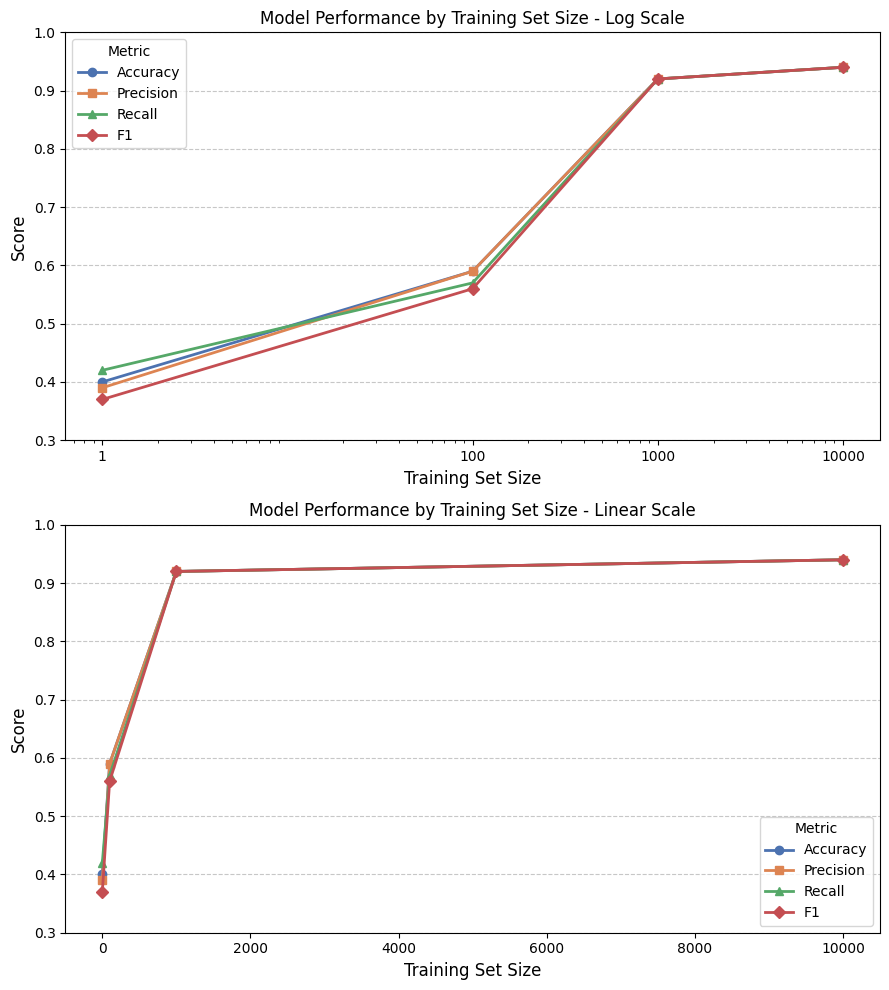

In [ ]:
# @title Graph output
import matplotlib.pyplot as plt
import numpy as np

data_sizes = [1, 100, 1000, 10000]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

scores = np.array([
    [0.40, 0.39, 0.42, 0.37],
    [0.59, 0.59, 0.57, 0.56],
    [0.92, 0.92, 0.92, 0.92],
    [0.94, 0.94, 0.94, 0.94],
])

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(9, 10))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
markers = ['o', 's', '^', 'D']

for i, (metric, color, marker) in enumerate(zip(metrics, colors, markers)):
  ax1.plot(data_sizes, scores[:, i], label=metric,
          color=color, marker=marker,
          markersize=6, linewidth=2)
  ax2.plot(data_sizes, scores[:, i], label=metric,
          color=color, marker=marker,
          markersize=6, linewidth=2)

ax1.set_xscale('log')
ax1.set_xticks(data_sizes)
ax1.set_xticklabels([str(s) for s in data_sizes])
ax1.set_title('Model Performance by Training Set Size - Log Scale', fontsize=12)
ax2.set_title('Model Performance by Training Set Size - Linear Scale', fontsize=12)


for ax in (ax1, ax2):
  ax.set_xlabel('Training Set Size', fontsize=12)
  ax.set_ylabel('Score', fontsize=12)
  ax.set_ylim(0.3, 1)
  ax.legend(title='Metric')
  ax.yaxis.grid(True, linestyle='--', alpha=0.7)
  ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_metrics.png', dpi=150)
plt.show()

In [19]:
# @title Error Analysis

test_subset = test.sample(n=1000, random_state=30)
y_true = test_subset['label'].tolist()
y_pred = []

for text in tqdm(test_subset['text']):
  inputs = tokenizer(
      [f"<s>[INST] Is this person who wrote this depressed or not depressed? Answer 1 if depressed and 0 if not. Do not output anything else. Text: {text} [/INST]"],
      return_tensors="pt"
  ).to("cuda")

  outputs = model.generate(
    **inputs,
    max_new_tokens = 2,
    max_length = None,
    use_cache = True,
    pad_token_id = tokenizer.eos_token_id
  )

  prediction = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:])[0]
  clean_pred = prediction.strip()
  if '1' in clean_pred:
      y_pred.append(1)
  else:
      y_pred.append(0)

wrong_predictions = [0,0]

for i in range(len(y_pred)):
  if y_pred[i] != y_true[i]:
    if y_pred[i] == 1:
      wrong_predictions[0] += 1
    else:
      wrong_predictions[1] += 1
    print(f"Text: {test_subset['text'].iloc[i]}; Prediction: {y_pred[i]}; Actual: {y_true[i]}")

print(f"False Positives: {wrong_predictions[0]}, False Negatives: {wrong_predictions[1]}")

100%|██████████| 1000/1000 [04:43<00:00,  3.53it/s]

Text: You guys ever feel like your alone? When I say alone I mean like...your all by yourself in the world. You might have someone dear to you that's with you and might love you but they may not be there all the time. I try not to feel so alone. I've been trying to post more on Reddit because it's really the only time I get any notifications. And I won't lie. Notifications from Reddit feel pretty good to me. And from my loved one. But I barely get any of those anymore..; Prediction: 1; Actual: 0.0
Text: Can you help me find the words I need? I feel as though I have been tempered to the point of nearly entire numbness emotionally, yet also there is a large portion of me that just hurts *so much*. It's like it's so numb it hurts, but what does that even mean? How can I get better if I hardly understand the problem?; Prediction: 1; Actual: 0.0
Text: Haha funny meme Homeschooled, have no job, can't drive so no social life 😎. Lost all contact with ex, best friend is fake and two faced, chil